# `bw_timex` Teaching Example - Time-explicit LCA of an Electric Vehicle

Here's a rundown of the steps involved in a `TimexLCA`:

<div style="display: flex; justify-content: center; background-color: white; border-radius: 15px; padding: 10px; width: 600px; margin: auto;">
  <img src="./data/method_overview.png" style="border-radius: 15px; width: 100%;">
</div>

## **Step 0**: Initial Setup _(normal brightway stuff)_


```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery):::ei-->ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable):::ei-->ev_production
    ev_production(🔌🚗 ev assembly):::fg-->driving
    electricity_generation(⚡ market group for electricity, low voltage):::ei-->driving
    driving(🛣️ driving ev):::fg-->battery_eol(🗑️🔋 market for used Li-ion battery):::ei
    driving-->fu(FU: driving 100,000 km)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

Legend:

```mermaid
flowchart TB
    background(background process):::ei
    foreground(foreground process):::fg

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


In [1]:
import bw2data as bd

bd.projects.set_current("timex_brightcon")

if "foreground" in bd.databases:
    del bd.databases["foreground"]  # to make sure we create the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

### Creating foreground processes


In [2]:
ev_production = foreground.new_node(
    "ev_production", name="assembly of an electric vehicle", unit="unit"
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

driving = foreground.new_node(
    "driving", name="driving an electric vehicle", unit="pkm over ev lifetime"
)
driving["reference product"] = "person transport"
driving.save()

### Adding exchanges


In [3]:
LIFETIME = 15  # years
ELECTRICITY_CONSUMPTION = 0.2  # kWh/km
LIFETIME_KM = 100_000  # km
MASS_CAR_WITHOUT_BATTERY = 840  # kg
MASS_BATTERY = 280  # kg

BG_DATABASE = "ei_cutoff_3.12_remind-eu_SSP2-NDC_2020"

In [4]:
car_without_battery = bd.get_node(
    database=BG_DATABASE,
    name="market for passenger car, electric, without battery",
)
battery = bd.get_node(
    database=BG_DATABASE,
    name="market for battery, Li-ion, LiMn2O4, rechargeable",
)
electricity = bd.get_node(
    database=BG_DATABASE,
    name="market group for electricity, low voltage",
    location="GLO",
)
battery_eol = bd.get_node(
    database=BG_DATABASE,
    name="market for used Li-ion battery",
)

In [5]:
ev_production.new_edge(input=ev_production, amount=1, type="production").save()

car_without_battery_to_ev = ev_production.new_edge(
    input=car_without_battery, amount=MASS_CAR_WITHOUT_BATTERY, type="technosphere"
)
car_without_battery_to_ev.save()

battery_to_ev = ev_production.new_edge(
    input=battery, amount=MASS_BATTERY, type="technosphere"
)
battery_to_ev.save()

In [6]:
driving.new_edge(input=driving, amount=1, type="production").save()

ev_to_driving = driving.new_edge(input=ev_production, amount=1, type="technosphere")
ev_to_driving.save()

electricity_to_driving = driving.new_edge(
    input=electricity,
    amount=ELECTRICITY_CONSUMPTION * LIFETIME_KM,
    type="technosphere",
)
electricity_to_driving.save()

driving_to_battery_eol = driving.new_edge(
    input=battery_eol,
    amount=-MASS_BATTERY,  # used battery is "produced"
    type="technosphere",
)
driving_to_battery_eol.save()

### Running a standard "static" LCA


In [7]:
import bw2calc as bc

method = (
    "ecoinvent-3.12",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)
standard_lca = bc.LCA({driving: 1}, method)
standard_lca.lci()
standard_lca.lcia()
standard_lca.score

/Users/timodiepers/Documents/Coding/brightcon-2026-material/courses/intermediate/timex_course/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 8.06e+12)
  warnings.warn(msg, UmfpackWarning)


23029.172113266824

## **Step 1**: Adding temporal information


```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery):::ei-->|1-2 years prior|ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable):::ei-->|6-9 months prior|ev_production
    ev_production(🔌🚗 ev assembly):::fg-->|1-3 months prior|driving
    electricity_generation(⚡ market group for electricity, low voltage):::ei-->|uniformly distributed over lifetime|driving
    driving(🛣️ driving ev):::fg-->|3 months after lifetime|battery_eol(🗑️🔋 market for used Li-ion battery):::ei
    driving-->fu(**FU**: driving 100,000 km, *uniformly over lifetime, starting 2025*)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


### The `TemporalDistribution` class


In [8]:
from bw_timex import TemporalDistribution
import numpy as np

td_car_without_battery_production = TemporalDistribution(
    date=np.array([-2, -1], dtype="timedelta64[Y]"),  # yearly resolution
    amount=np.array([0.2, 0.8]),
)

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2, -1], dtype="timedelta64[M]"),  # monthly resolution
    amount=np.array([0.3, 0.5, 0.2]),
)

#### Creating the remaining TDs


In [9]:
from bw_timex import easy_timedelta_distribution

td_battery_production = easy_timedelta_distribution(
    start=-9,
    end=-6,
    resolution="M",
    steps=4,
    kind="normal",  # you can also use "uniform" or "triangular"
    param=0.5,
)

td_electricity_consumption = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform",
)

td_battery_eol = TemporalDistribution(
    date=np.array([LIFETIME * 12 + 3], dtype="timedelta64[M]"), amount=np.array([1])
)

#### Adding TDs to the exchanges


In [10]:
car_without_battery_to_ev["temporal_distribution"] = td_car_without_battery_production
car_without_battery_to_ev.save()

battery_to_ev["temporal_distribution"] = td_battery_production
battery_to_ev.save()

ev_to_driving["temporal_distribution"] = td_assembly_and_delivery
ev_to_driving.save()

# if you dont have the exchange object at hand, you can also use our util function:
from bw_timex.utils import add_temporal_distribution_to_exchange

add_temporal_distribution_to_exchange(
    td_electricity_consumption,
    input_node=electricity,
    output_node=driving,
)

add_temporal_distribution_to_exchange(
    td_battery_eol,
    input_node=battery_eol,
    output_node=driving,
)

2026-09-14 12:27:21.702 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 20000.0 kilowatt hour 'market group for electricity, low voltage' (kilowatt hour, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).
2026-09-14 12:27:21.705 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -280 kilogram 'market for used Li-ion battery' (kilogram, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).


### Prospective background databases

Created with [`premise`](https://github.com/polca/premise) following the REMIND-EU SSP2 NDC scenario.
premise >= 2.4.9.2 writes the point in time each database represents as `representative_time`
metadata on the database itself, so `bw_timex` finds it automatically - no mapping needed in this
script. For databases from an earlier premise, set it yourself with `set_database_metadata`, or
pass `database_dates` to `TimexLCA` to map (or override) it directly.

## **Step 2**: Building the process timeline


In [11]:
from bw_timex import TimexLCA

tlca = TimexLCA({driving: 1}, method)

2026-09-14 12:27:21.710 | INFO     | bw_timex.timex_lca:__init__:444 - Initializing TimexLCA object...
2026-09-14 12:27:21.712 | INFO     | bw_timex.timex_lca:__init__:533 - Calculating base LCA...
2026-09-14 12:27:21.713 | INFO     | bw_timex.timex_lca:clean_databases:2475 - Reprocessing 1 modified database(s) before calculating: foreground. This can take a while for large databases.
2026-09-14 12:27:21.722 | INFO     | bw_timex.timex_lca:clean_databases:2481 - Done reprocessing modified databases.
/Users/timodiepers/Documents/Coding/brightcon-2026-material/courses/intermediate/timex_course/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 8.06e+12)
  warnings.warn(msg, UmfpackWarning)
2026-09-14 12:27:22.601 | INFO     | bw_timex.timex_lca:__init__:588 - Collecting node infos...
2026-09-14 12:27:22.646 | INFO     | bw_timex.timex_lca:__init__:603 - Loading node metadata from 5 database(s)...
2026-09-1

In [12]:
tlca.build_timeline(
    starting_datetime="2025-01-01", temporal_grouping="month", graph_traversal="bfs"
)

2026-09-14 12:27:28.335 | INFO     | bw_timex.timex_lca:build_timeline:1251 - No edge filter function provided. Skipping all edges in background databases.
2026-09-14 12:27:33.777 | INFO     | bw_timex.timex_lca:build_timeline:1274 - Creating activity time mapping...
2026-09-14 12:27:33.926 | INFO     | bw_timex.timeline_builder:__init__:119 - Traversing supply chain graph...
2026-09-14 12:27:33.947 | INFO     | bw_timex.timeline_builder:build_timeline:190 - Building timeline...


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2022-10-01,"market for passenger car, electric, without ba...",2024-10-01,assembly of an electric vehicle,168.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.7...
1,2022-11-01,"market for passenger car, electric, without ba...",2024-11-01,assembly of an electric vehicle,168.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.7...
2,2022-12-01,"market for passenger car, electric, without ba...",2024-12-01,assembly of an electric vehicle,168.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.7...
3,2023-10-01,"market for passenger car, electric, without ba...",2024-10-01,assembly of an electric vehicle,672.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.6...
4,2023-11-01,"market for passenger car, electric, without ba...",2024-11-01,assembly of an electric vehicle,672.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.6...
5,2023-12-01,"market for passenger car, electric, without ba...",2024-12-01,assembly of an electric vehicle,672.0,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.6...
6,2024-01-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,assembly of an electric vehicle,54.695544,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.6...
7,2024-02-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,assembly of an electric vehicle,85.304456,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.5...
8,2024-02-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-11-01,assembly of an electric vehicle,54.695544,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.5...
9,2024-03-01,"market for battery, Li-ion, LiMn2O4, rechargeable",2024-10-01,assembly of an electric vehicle,85.304456,{'ei_cutoff_3.12_remind-eu_SSP2-NDC_2020': 0.5...


Temporalized product system for reference:

```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery):::ei-->|1-2 years prior|ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable):::ei-->|6-9 months prior|ev_production
    ev_production(🔌🚗 ev assembly):::fg-->|1-3 months prior|driving
    electricity_generation(⚡ market group for electricity, low voltage):::ei-->|uniformly distributed over lifetime|driving
    driving(🛣️ driving ev):::fg-->|3 months after lifetime|battery_eol(🗑️🔋 market for used Li-ion battery):::ei
    driving-->fu(**FU**: driving 100,000 km, *uniformly over lifetime, starting 2025*)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


## **Step 3**: Calculating the time-explicit LCI


In [13]:
tlca.lci()

2026-09-14 12:27:34.780 | INFO     | bw_timex.timex_lca:lci:1440 - Expanding matrices...
2026-09-14 12:27:34.799 | INFO     | bw_timex.timex_lca:lci:1459 - Calculating dynamic inventory...
/Users/timodiepers/Documents/Coding/brightcon-2026-material/courses/intermediate/timex_course/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 2.02e+13)
  warnings.warn(msg, UmfpackWarning)


Under the hood, before solving the inventory problem, we're re-build the technosphere and biosphere matrices here. New rows and columns are added to carry the extra temporal information. Details are explained in the [Theory Section](https://docs.brightway.dev/projects/bw-timex/en/latest/content/theory.html#modifying-the-matrices) of our docs.


## **Step 4**: Impact assessment


The simplest case, static LCIA:


In [14]:
tlca.static_lcia()
tlca.static_score

14388.13797694324

Compare this to the score of our "normal" static lca before:

In [15]:
standard_lca.score

23029.172113266824

Compare the size of the technosphere matrices:

In [16]:
tlca.lca.technosphere_matrix

<196809x196809 sparse matrix of type '<class 'numpy.float64'>'
	with 2221774 stored elements in Compressed Sparse Row format>

In [17]:
standard_lca.technosphere_matrix

<49181x49181 sparse matrix of type '<class 'numpy.float64'>'
	with 554150 stored elements in Compressed Sparse Row format>

... and the resulting inventory:

In [18]:
standard_lca.inventory

<3341x49181 sparse matrix of type '<class 'numpy.float64'>'
	with 472417 stored elements in Compressed Sparse Row format>

In [19]:
tlca.lca.inventory

<3341x196809 sparse matrix of type '<class 'numpy.float64'>'
	with 1911050 stored elements in Compressed Sparse Row format>

Because `bw_timex` retains temporal information in the inventory, we can apply dynamic LCIA:


In [20]:
tlca.dynamic_lcia(metric="GWP")

2026-09-14 12:28:42.895 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,2023-01-01,-0.002927,357793171271798859,357834687643570178
1,2023-01-01,-0.001756,357793171271798859,357834687643570177
2,2023-01-01,-0.001171,357793171271798859,357834687643570179
3,2023-01-01,-0.000201,357793171569594445,357834687643570178
4,2023-01-01,-0.000121,357793171569594445,357834687643570177
...,...,...,...,...
2547,2040-01-01,11.817527,357793171645091961,357834687643570209
2548,2040-01-01,14.223779,357793171628314637,357834687643570209
2549,2040-01-01,19.606390,357793171913527315,357834687643570209
2550,2040-01-01,41.510877,357793171326324818,357834687643570209


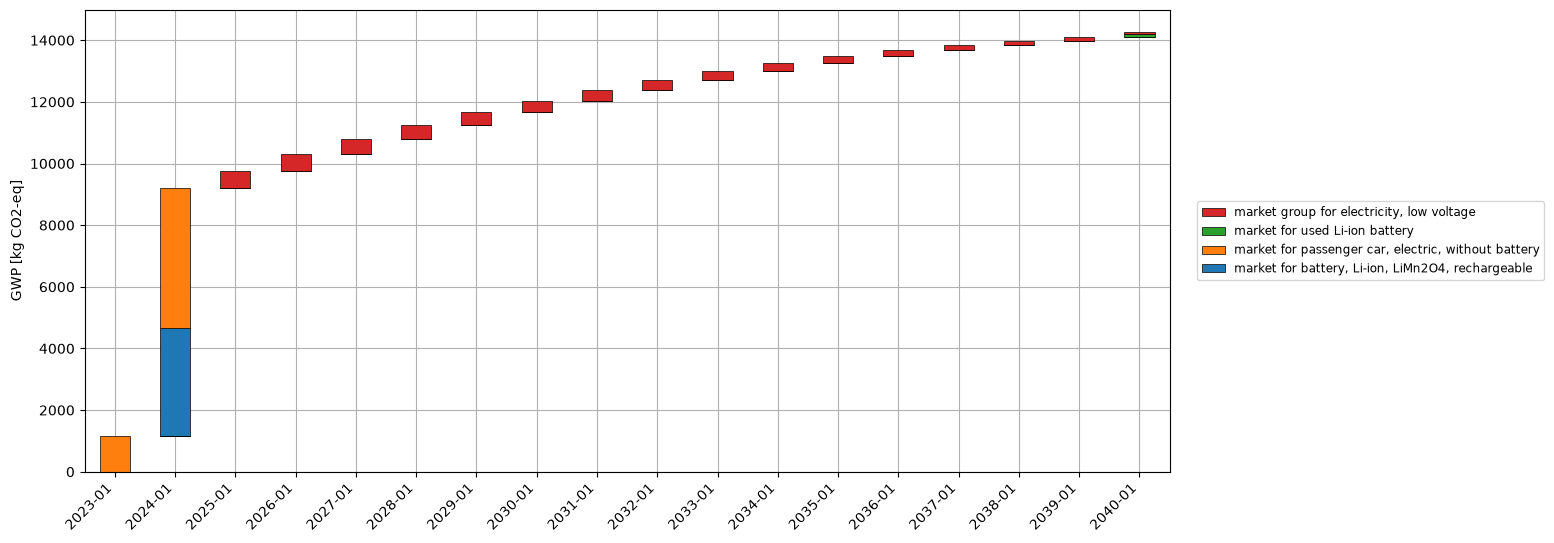

In [21]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

plot_characterized_inventory_as_waterfall(tlca)

In addition to the "standard" GWP, we can go even more dynamic, directly assessing radiative forcing:


In [22]:
tlca.dynamic_lcia(
    metric="radiative_forcing",
    time_horizon=30,
)

2026-09-14 12:28:44.639 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,2024-01-01 05:49:12,-4.821176e-18,357793171271798859,357834687643570178
1,2024-01-01 05:49:12,-2.892690e-18,357793171271798859,357834687643570177
2,2024-01-01 05:49:12,-1.928482e-18,357793171271798859,357834687643570179
3,2024-01-01 05:49:12,-3.309844e-19,357793171569594445,357834687643570178
4,2024-01-01 05:49:12,-1.985930e-19,357793171569594445,357834687643570177
...,...,...,...,...
59155,2068-12-31 00:46:48,9.543027e-15,357793171628314637,357834687643570209
59156,2068-12-31 00:46:48,1.119260e-14,357793171645091961,357834687643570209
59157,2068-12-31 00:46:48,1.856957e-14,357793171913527315,357834687643570209
59158,2068-12-31 00:46:48,3.931571e-14,357793171326324818,357834687643570209


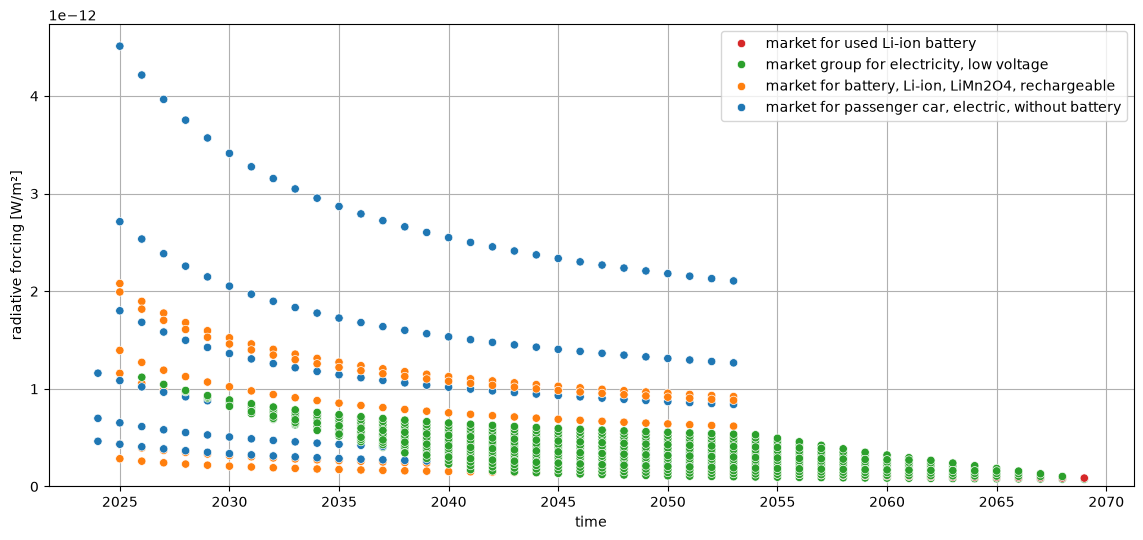

In [23]:
tlca.plot_dynamic_characterized_inventory(
    sum_emissions_within_activity=True,
)

## Quick Recap
This might have seemed quite lengthy now. But essentially, calculating a `TimexLCA` is just this:

In [24]:
tlca = TimexLCA(demand={driving: 1}, method=method)
tlca.build_timeline(starting_datetime="2025-01-01", temporal_grouping="month", graph_traversal="bfs")
tlca.lci()
tlca.static_lcia()
tlca.static_score

2026-09-14 12:28:46.551 | INFO     | bw_timex.timex_lca:__init__:444 - Initializing TimexLCA object...
2026-09-14 12:28:46.558 | INFO     | bw_timex.timex_lca:__init__:533 - Calculating base LCA...
/Users/timodiepers/Documents/Coding/brightcon-2026-material/courses/intermediate/timex_course/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 8.06e+12)
  warnings.warn(msg, UmfpackWarning)
2026-09-14 12:28:48.075 | INFO     | bw_timex.timex_lca:__init__:588 - Collecting node infos...
2026-09-14 12:28:48.161 | INFO     | bw_timex.timex_lca:__init__:603 - Loading node metadata from 5 database(s)...
2026-09-14 12:28:48.375 | INFO     | bw_timex.timex_lca:__init__:648 - TimexLCA initialized.
2026-09-14 12:28:48.432 | INFO     | bw_timex.timex_lca:build_timeline:1251 - No edge filter function provided. Skipping all edges in background databases.
2026-09-14 12:29:01.042 | INFO     | bw_timex.timex_lca:build_timel

14388.13797694324